# Exploratory Data Analysis

## Objective

The purpose of this notebook is to understand the student performance dataset and identify the factors most strongly associated with academic success.

Questions investigated:

- What is the distribution of exam scores?
- Is placement status balanced?
- Which variables correlate with exam performance?
- How do study habits influence outcomes?
- Which features appear most useful for prediction?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/student_dataset_10000_rows.csv")

In [2]:
df.head()

df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 625.1 KB


study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

No missing values were detected in the dataset.

<Axes: >

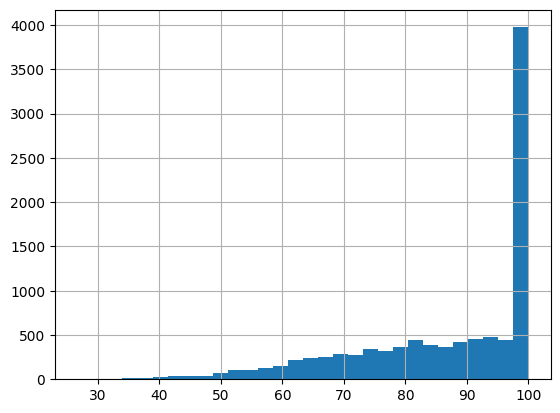

In [3]:
df["exam_score"].hist(
    bins=30
)

A large proportion of students achieved the maximum score of 100, creating a ceiling effect in the distribution.

This characteristic suggests the dataset may contain synthetic relationships and could affect model performance.

In [4]:
df["placement_status"].value_counts()

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64

<Axes: xlabel='placement_status', ylabel='count'>

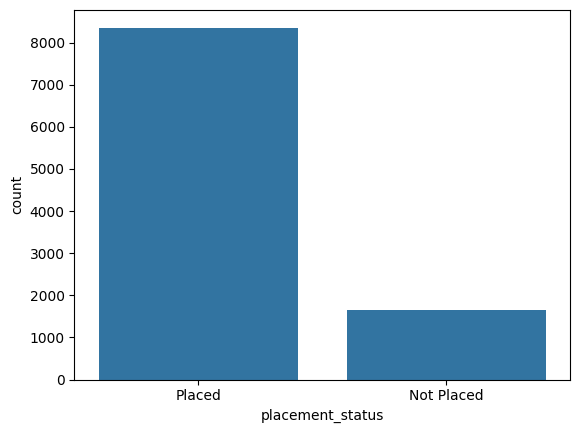

In [5]:
sns.countplot(
    data=df,
    x="placement_status"
)

The dataset is imbalanced.

Approximately 84% of students are classified as Placed, while only 16% are classified as Not Placed.

This imbalance should be considered during classification model evaluation.

<Axes: >

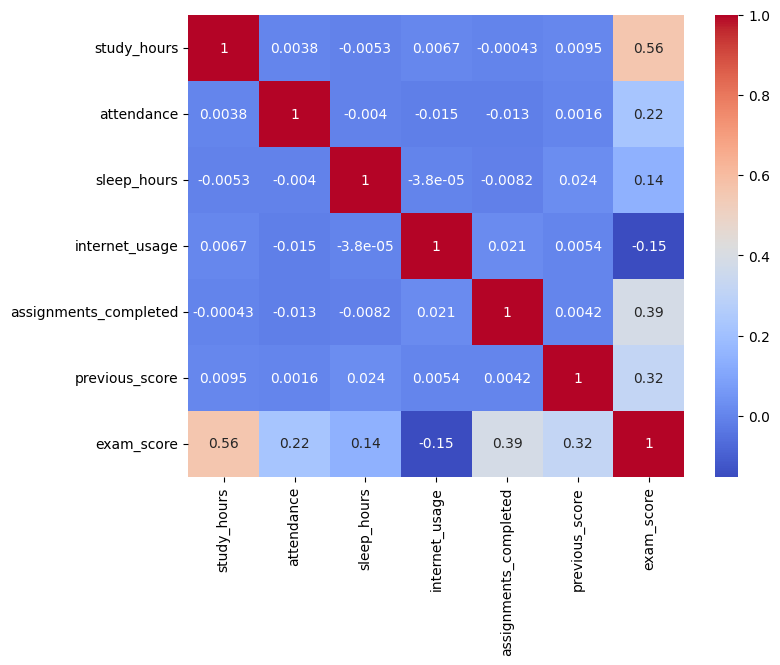

In [6]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [7]:
corr["exam_score"].sort_values(
    ascending=False
)

exam_score               1.000000
study_hours              0.562528
assignments_completed    0.387609
previous_score           0.318805
attendance               0.223367
sleep_hours              0.144675
internet_usage          -0.151896
Name: exam_score, dtype: float64

Study hours exhibited the strongest correlation with exam performance, followed by assignments completed and previous scores.

Internet usage showed a weak negative relationship with exam score.

<Axes: xlabel='study_hours', ylabel='exam_score'>

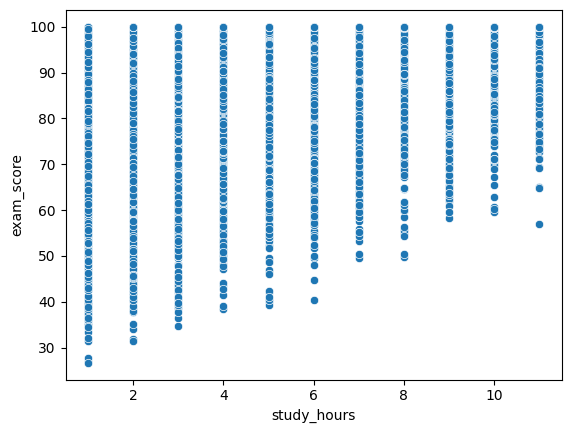

In [8]:
sns.scatterplot(
    data=df,
    x="study_hours",
    y="exam_score"
)

Students who study more hours generally achieve higher exam scores.

<Axes: xlabel='attendance', ylabel='exam_score'>

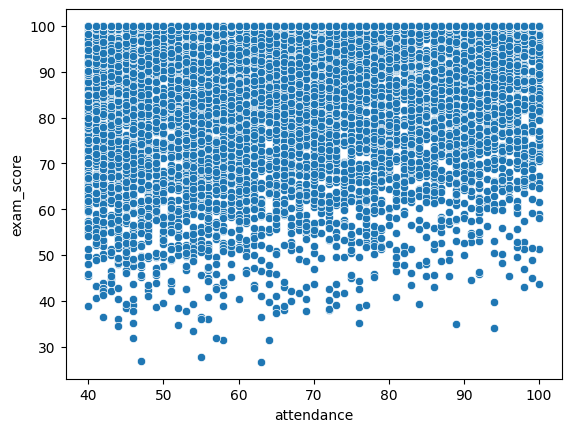

In [9]:
sns.scatterplot(
    data=df,
    x="attendance",
    y="exam_score"
)

Attendance appears positively related to exam performance, although the relationship is weaker than study hours.

ValueError: Could not interpret value `performance_group` for `x`. An entry with this name does not appear in `data`.

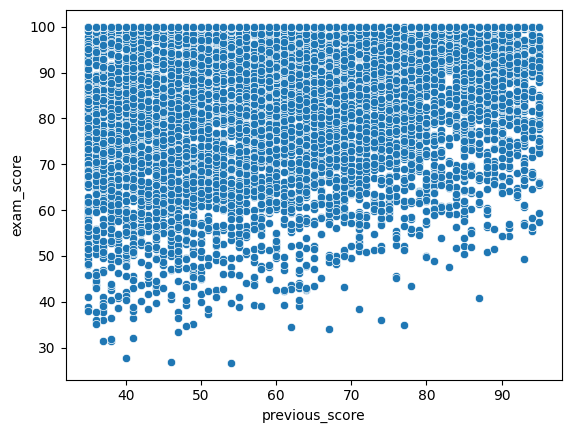

<Figure size 800x500 with 0 Axes>

In [ ]:
sns.scatterplot(
    data=df,
    x="previous_score",
    y="exam_score"
)

Historical academic performance appears to be a meaningful predictor of future results.

# Key Findings

## Dataset Characteristics

- The dataset contains 10,000 student records.
- No missing values were detected.
- Exam scores exhibit a ceiling effect, with many students achieving the maximum score.

## Placement Status

- 83.6% of students were classified as Placed.
- 16.4% were classified as Not Placed.
- Classification models should be evaluated using metrics beyond accuracy.

## Factors Associated with Exam Performance

Correlation analysis identified:

1. Study Hours (0.56)
2. Assignments Completed (0.39)
3. Previous Score (0.32)

as the strongest predictors of exam performance.

## Initial Hypothesis

Student engagement indicators such as study hours, assignment completion, and attendance are expected to play a significant role in predictive modeling tasks.